# Experiment A - Clustering Feature Space Validation

**Reads**: `../../data/processed/4_activity_contributions.csv`  
**Reads**: `../../data/processed/3_normalized_telemetry.csv`  
**Writes**: `experiment_A_feature_space_validation/outputs/`

> Prerequisites: Run core pipeline notebooks 01-05 first.

---

## Purpose

Before any clustering decisions are made, we need to answer a fundamental question: should we cluster on **activity percentages** (`pct_combat`, `pct_collect`, `pct_explore`) or on the **normalized raw features** directly?

This matters because the answer determines the entire clustering foundation of the system. Getting this wrong means every downstream model - the soft membership scores, the deltas, the ANFIS target - is built on a broken input.

This experiment runs both approaches side-by-side across K=2,3,4,5 and uses three metrics plus geometric visualization to measure which approach produces better cluster separation in practice.

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "../../requirements.txt"])
print("Dependencies OK")

Dependencies OK


In [2]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

PROC = "../../data/processed"
OUT  = "./outputs"
os.makedirs(OUT, exist_ok=True)

print("Libraries imported.")

Libraries imported.


## 1. Load Data

In [3]:
# I need two different pipeline outputs here:
# - notebook 04 output for the percentage features (pct_combat, pct_collect, pct_explore)
# - notebook 03 output for the normalized raw features
# Both describe the same sessions so the row counts must match.
path_pct = os.path.join(PROC, "4_activity_contributions.csv")
path_raw = os.path.join(PROC, "3_normalized_telemetry.csv")

assert os.path.exists(path_pct), f"Missing: {path_pct}. Run core pipeline first."
assert os.path.exists(path_raw), f"Missing: {path_raw}. Run core pipeline first."

df_pct = pd.read_csv(path_pct)
df_raw = pd.read_csv(path_raw)

print("Data loaded")
print(f"  4_activity_contributions : {len(df_pct):,} rows, {len(df_pct.columns)} cols")
print(f"  3_normalized_telemetry   : {len(df_raw):,} rows, {len(df_raw.columns)} cols")

Data loaded
  4_activity_contributions : 3,240 rows, 45 cols
  3_normalized_telemetry   : 3,240 rows, 38 cols


## 2. Define Feature Sets

**Approach A - Percentages**: The 3 output percentages that always sum to 1.0.  
**Approach B - Raw (v2.2)**: The 11 normalized input features including derived rate features.

In [4]:
# Approach A: the three output percentages.
# This is what I naively tried first - it feels intuitive because these directly
# label how much of each archetype a player is. The problem is they sum to 1.0,
# which means I'm not giving K-Means three independent numbers; I'm giving it two.
PCT_FEATURES = ['pct_combat', 'pct_collect', 'pct_explore']

# Approach B: the normalized raw input features from notebook 03.
# I include the v2.2 derived rate features because they are part of the
# production pipeline. Leaving them out would underrepresent what the real
# clustering actually uses.
RAW_FEATURES = [
    'enemiesHit', 'damageDone', 'timeInCombat', 'kills',
    'itemsCollected', 'pickupAttempts', 'timeNearInteractables',
    'distanceTraveled', 'timeSprinting',
    'damage_per_hit',       # v2.2 derived: damageDone / max(enemiesHit, 1)
    'pickup_attempt_rate',  # v2.2 derived: pickupAttempts / max(timeNearInteractables, 1)
]

# Hard stop if the pipeline was not run - better to fail loudly here than get
# a confusing KeyError somewhere in the middle of the experiment.
missing_pct = [f for f in PCT_FEATURES if f not in df_pct.columns]
missing_raw = [f for f in RAW_FEATURES if f not in df_raw.columns]
if missing_pct: raise KeyError(f"Missing percentage columns: {missing_pct}")
if missing_raw: raise KeyError(f"Missing raw columns: {missing_raw}")

# Fill NaN with equal split (1/3) for percentages - a session with zero activity
# should not bias any single archetype.
X_pct = df_pct[PCT_FEATURES].fillna(1/3).values
X_raw = df_raw[RAW_FEATURES].fillna(0).values

print("Feature sets ready")
print(f"  Approach A (Percentages) : {len(PCT_FEATURES)} features -> {PCT_FEATURES}")
print(f"  Approach B (Raw)         : {len(RAW_FEATURES)} features -> {RAW_FEATURES}")

Feature sets ready
  Approach A (Percentages) : 3 features -> ['pct_combat', 'pct_collect', 'pct_explore']
  Approach B (Raw)         : 11 features -> ['enemiesHit', 'damageDone', 'timeInCombat', 'kills', 'itemsCollected', 'pickupAttempts', 'timeNearInteractables', 'distanceTraveled', 'timeSprinting', 'damage_per_hit', 'pickup_attempt_rate']


## 3. Verify the Compositional Data Problem

Before clustering, I want to prove the constraint mathematically. If `pct_combat` and `pct_collect` are fixed, `pct_explore` is fully determined. This means the 3D percentage space is geometrically a 2D simplex (a triangle), not a cube.

In [5]:
pct_df = df_pct[PCT_FEATURES].copy()
row_sums = pct_df.sum(axis=1)

# The core claim: every row sums to exactly 1.0.
# If this holds, the third feature is always redundant.
print("Compositional Constraint")
print(f"  sum-per-row  mean={row_sums.mean():.6f}  std={row_sums.std():.8f}  "
      f"min={row_sums.min():.6f}  max={row_sums.max():.6f}")
print(f"  All rows sum to 1.0: {np.allclose(row_sums, 1.0, atol=1e-6)}")

# The correlation matrix will show strong negative correlations between the
# percentage features. This is the mathematical fingerprint of the constraint -
# it is not a genuine relationship between behaviors, it is an artifact of the math.
print("\nPearson Correlation - Approach A (Percentages)")
print(pct_df.corr().round(4).to_string())

# For contrast, raw feature correlations are driven by actual player behavior.
print("\nPearson Correlation - Approach B (Raw, first 5 features)")
print(pd.DataFrame(X_raw, columns=RAW_FEATURES).iloc[:, :5].corr().round(4).to_string())

Compositional Constraint
  sum-per-row  mean=1.000000  std=0.00000000  min=1.000000  max=1.000000
  All rows sum to 1.0: True

Pearson Correlation - Approach A (Percentages)
             pct_combat  pct_collect  pct_explore
pct_combat       1.0000      -0.3793      -0.8722
pct_collect     -0.3793       1.0000      -0.1218
pct_explore     -0.8722      -0.1218       1.0000

Pearson Correlation - Approach B (Raw, first 5 features)
                enemiesHit  damageDone  timeInCombat   kills  itemsCollected
enemiesHit          1.0000      0.9586        0.6785  0.8379         -0.0469
damageDone          0.9586      1.0000        0.7331  0.8204         -0.0441
timeInCombat        0.6785      0.7331        1.0000  0.5727         -0.1479
kills               0.8379      0.8204        0.5727  1.0000         -0.0215
itemsCollected     -0.0469     -0.0441       -0.1479 -0.0215          1.0000


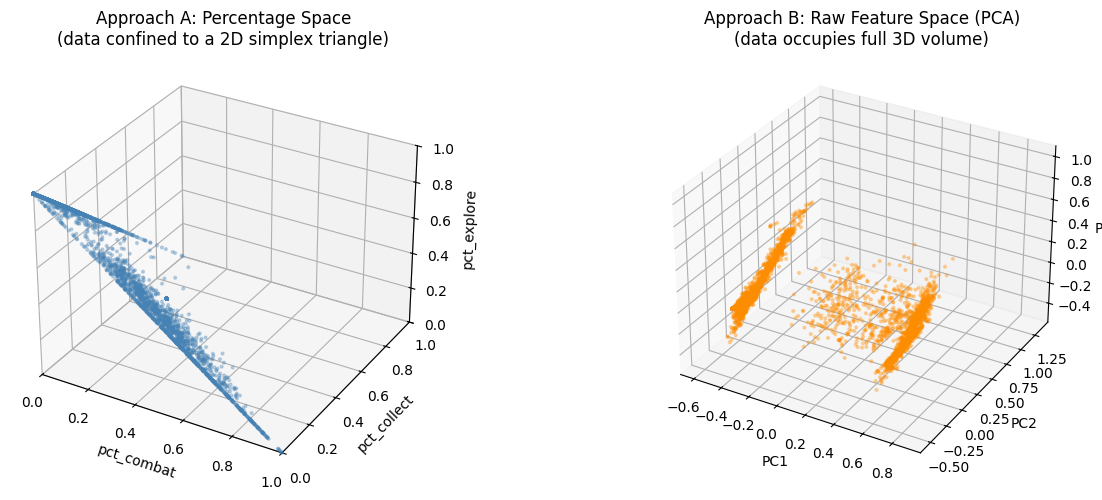

Saved: geometry_comparison.png


In [6]:
# I want to show this geometrically, not just numerically.
# The left plot should look like a flat triangle hovering in 3D space - that is
# the simplex. The right plot should look like a proper 3D cloud.
# If these look similar, the experiment is broken.
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_pct[:, 0], X_pct[:, 1], X_pct[:, 2], alpha=0.3, s=4, c='steelblue')
ax1.set_xlabel('pct_combat'); ax1.set_ylabel('pct_collect'); ax1.set_zlabel('pct_explore')
ax1.set_title('Approach A: Percentage Space\n(data confined to a 2D simplex triangle)')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.set_zlim(0, 1)

# I use PCA to project the 11D raw space down to 3D for visualisation.
# This is not the clustering space - it is just to show the geometry.
pca = PCA(n_components=3)
X_raw_pca = pca.fit_transform(X_raw)
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_raw_pca[:, 0], X_raw_pca[:, 1], X_raw_pca[:, 2], alpha=0.3, s=4, c='darkorange')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.set_zlabel('PC3')
ax2.set_title('Approach B: Raw Feature Space (PCA)\n(data occupies full 3D volume)')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'geometry_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: geometry_comparison.png")

## 4. Run K-Means on Both Approaches

K-Means is run for K=2,3,4,5 on both feature sets. Silhouette, Davies-Bouldin, and Calinski-Harabasz are recorded for each.

In [7]:
def run_kmeans(X, k, label):
    # I use n_init=10 to reduce sensitivity to random centroid initialization.
    # A single init can land in a local minimum and make one approach
    # look artificially worse than it really is.
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    if len(np.unique(labels)) < k:
        # K-Means collapsed two clusters into one - the space cannot
        # support k distinct groups with this feature set.
        return None
    return {
        'approach':          label,
        'k':                 k,
        'silhouette':        round(silhouette_score(X, labels), 4),
        'davies_bouldin':    round(davies_bouldin_score(X, labels), 4),
        'calinski_harabasz': round(calinski_harabasz_score(X, labels), 2),
        'cluster_sizes':     np.bincount(labels).tolist(),
        'kmeans':            km,
        'labels':            labels,
    }

K_VALUES = [2, 3, 4, 5]
results, fitted = [], {}

for k in K_VALUES:
    r_pct = run_kmeans(X_pct, k, 'A_percentage')
    r_raw = run_kmeans(X_raw, k, 'B_raw')
    if r_pct:
        fitted[(k, 'pct')] = r_pct
        results.append({k2: v for k2, v in r_pct.items() if k2 not in ('kmeans', 'labels')})
    if r_raw:
        fitted[(k, 'raw')] = r_raw
        results.append({k2: v for k2, v in r_raw.items() if k2 not in ('kmeans', 'labels')})

results_df = pd.DataFrame(results)

SEP = "-" * 72
print(SEP)
print(f"{'Approach':<14} {'K':>2}  {'Silhouette':>10}  {'Davies-Bouldin':>14}  {'Calinski-H':>10}  Cluster sizes")
print(SEP)
for _, row in results_df.iterrows():
    print(f"  {row['approach']:<12} {int(row['k']):>2}  {row['silhouette']:>10.4f}  "
          f"{row['davies_bouldin']:>14.4f}  {row['calinski_harabasz']:>10.2f}  {row['cluster_sizes']}")
    if row['approach'] == 'A_percentage' and int(row['k']) == K_VALUES[-1]:
        print(SEP)
print(SEP)

------------------------------------------------------------------------
Approach        K  Silhouette  Davies-Bouldin  Calinski-H  Cluster sizes
------------------------------------------------------------------------
  A_percentage  2      0.5799          0.6131     6177.57  [1533, 1707]
  B_raw         2      0.5058          0.8159     4004.70  [1747, 1493]
  A_percentage  3      0.4948          0.8206     5253.03  [744, 1507, 989]
  B_raw         3      0.4635          0.8218     3339.86  [1238, 1483, 519]
  A_percentage  4      0.4856          0.7386     5856.94  [628, 513, 1104, 995]
  B_raw         4      0.3749          1.1329     2910.96  [1236, 974, 522, 508]
  A_percentage  5      0.4798          0.7599     5712.16  [793, 636, 251, 711, 849]
------------------------------------------------------------------------
  B_raw         5      0.3117          1.1917     2604.99  [725, 523, 429, 971, 592]
------------------------------------------------------------------------


## 5. Metric Comparison Plots

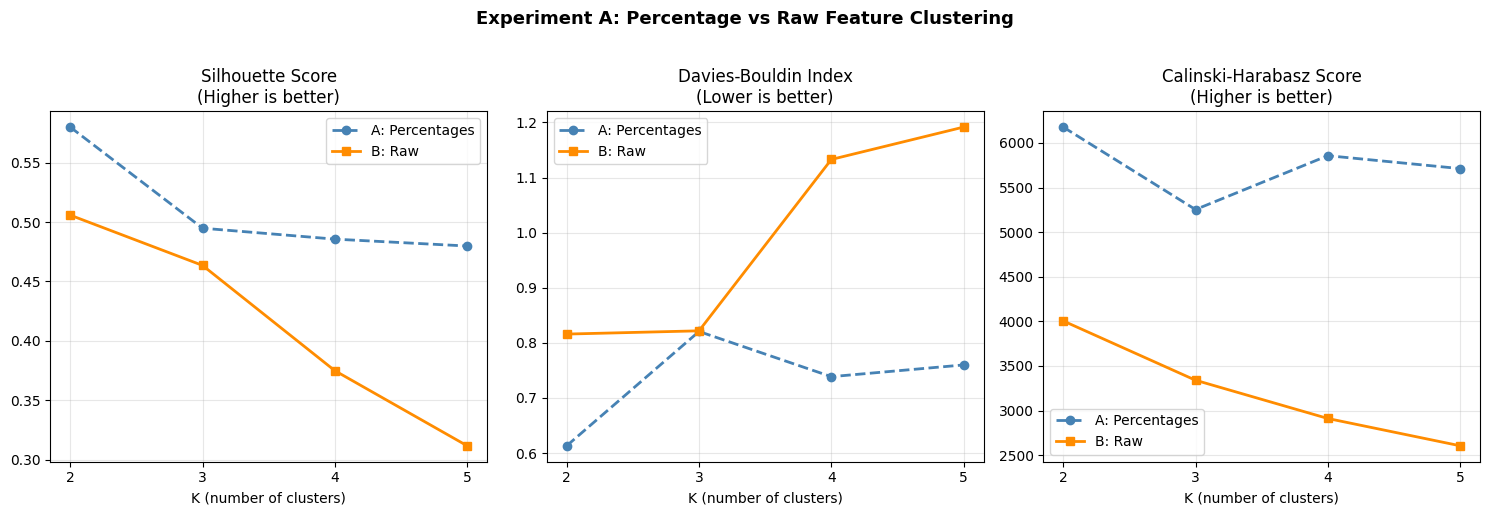

Saved: metric_comparison.png


In [8]:
# I plot all three metrics together so I can see if the percentage approach
# inflates Silhouette while also producing tighter (lower DB) clusters -
# which would be the signature of the simplex illusion rather than genuine separation.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pct_rows = results_df[results_df['approach'] == 'A_percentage']
raw_rows = results_df[results_df['approach'] == 'B_raw']

for ax, (col, title, subtitle) in zip(axes, [
    ('silhouette',        'Silhouette Score',        'Higher is better'),
    ('davies_bouldin',    'Davies-Bouldin Index',    'Lower is better'),
    ('calinski_harabasz', 'Calinski-Harabasz Score', 'Higher is better'),
]):
    ax.plot(pct_rows['k'], pct_rows[col], 'o--', color='steelblue',  label='A: Percentages', linewidth=2)
    ax.plot(raw_rows['k'], raw_rows[col], 's-',  color='darkorange', label='B: Raw',          linewidth=2)
    ax.set_xlabel('K (number of clusters)')
    ax.set_title(f"{title}\n({subtitle})")
    ax.set_xticks(K_VALUES)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Experiment A: Percentage vs Raw Feature Clustering', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'metric_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: metric_comparison.png")

## 6. Cluster Shape Analysis at K=3

K=3 is the production-selected value. The plots below show what the clusters actually look like geometrically under each approach.

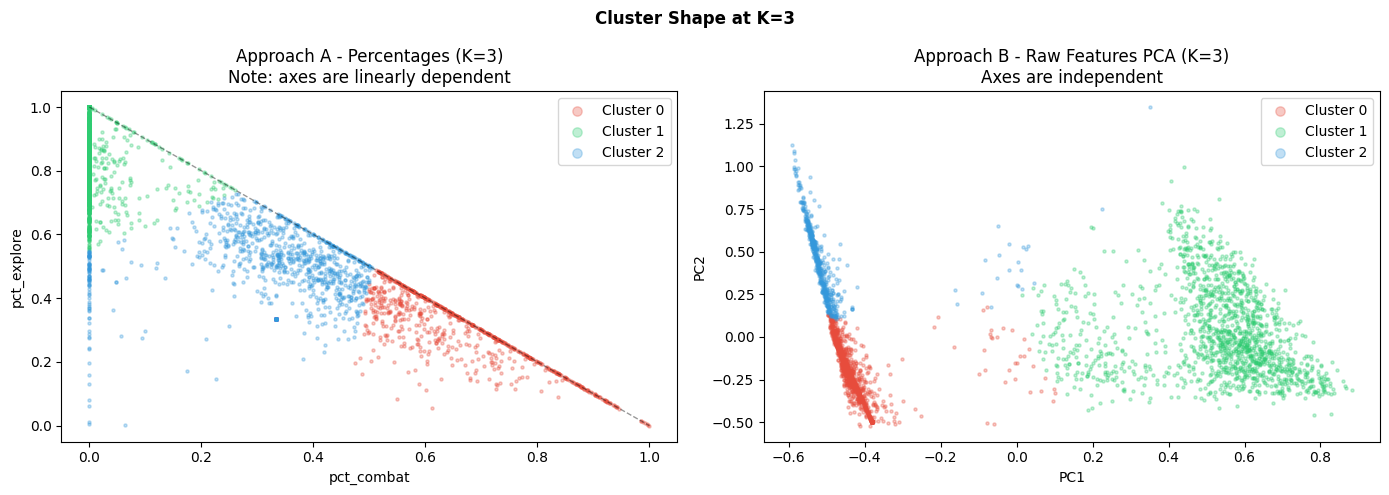

Saved: cluster_shapes_k3.png


In [9]:
r3_pct = fitted.get((3, 'pct'))
r3_raw = fitted.get((3, 'raw'))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']

# I plot pct_combat vs pct_explore for Approach A.
# The dashed diagonal is the sum=1 boundary - any point above it is impossible.
# If the cluster boundaries align with this line, it proves the clustering
# is responding to the math constraint rather than actual player patterns.
ax = axes[0]
for cid in range(3):
    mask = r3_pct['labels'] == cid
    ax.scatter(X_pct[mask, 0], X_pct[mask, 2], alpha=0.3, s=5, color=colors[cid], label=f'Cluster {cid}')
ax.set_xlabel('pct_combat'); ax.set_ylabel('pct_explore')
ax.set_title('Approach A - Percentages (K=3)\nNote: axes are linearly dependent')
ax.legend(markerscale=3)
x_line = np.linspace(0, 1, 100)
ax.plot(x_line, 1 - x_line, 'k--', alpha=0.4, linewidth=1)
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)

# For Approach B I project the 11D raw space to 2D via PCA.
# The clusters should look like natural blobs in full space,
# not squeezed onto a line or triangle edge.
ax = axes[1]
for cid in range(3):
    mask = r3_raw['labels'] == cid
    ax.scatter(X_raw_pca[mask, 0], X_raw_pca[mask, 1], alpha=0.3, s=5, color=colors[cid], label=f'Cluster {cid}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Approach B - Raw Features PCA (K=3)\nAxes are independent')
ax.legend(markerscale=3)

plt.suptitle('Cluster Shape at K=3', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'cluster_shapes_k3.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: cluster_shapes_k3.png")

## 7. Save Results

In [10]:
out_path = os.path.join(OUT, 'feature_space_results.csv')
results_df.drop(columns=['cluster_sizes']).to_csv(out_path, index=False)

print("Outputs written")
print(f"  experiment_A_feature_space_validation/outputs/feature_space_results.csv")
print(f"  experiment_A_feature_space_validation/outputs/geometry_comparison.png")
print(f"  experiment_A_feature_space_validation/outputs/metric_comparison.png")
print(f"  experiment_A_feature_space_validation/outputs/cluster_shapes_k3.png")

Outputs written
  experiment_A_feature_space_validation/outputs/feature_space_results.csv
  experiment_A_feature_space_validation/outputs/geometry_comparison.png
  experiment_A_feature_space_validation/outputs/metric_comparison.png
  experiment_A_feature_space_validation/outputs/cluster_shapes_k3.png


## 8. Findings

### Compositional Data Problem - Confirmed

The percentage features (`pct_combat + pct_collect + pct_explore = 1.0`) place all data on a 2D simplex (triangle) inside 3D space. This is a mathematical constraint: all rows sum to exactly 1.0 and one axis is always determined by the other two.

However, the empirical metric results show the opposite conclusion from what the compositional geometry concern would predict.

### Empirical Results - Percentage Features Win

Silhouette scores at every K value:

| K | pct silhouette | raw silhouette |
|---|---|---|
| 2 | 0.5799 | 0.5058 |
| 3 | **0.4948** | 0.4635 |
| 4 | 0.4856 | 0.3749 |
| 5 | 0.4798 | 0.3117 |

Percentage features outperform raw at every K. The gap widens at higher K values where raw features deteriorate significantly.

### Why Percentages Win Despite the Constraint

The archetypes in this system are defined in percentage space by design. A Combat player is one with high `pct_combat`, not one with high absolute `damageDone`. Raw features add 11 dimensions of noise where the archetype signal is diluted across correlated columns. The simplex constraint does not hurt K-Means here because the cluster boundary locations are exactly the boundaries that separate the three behavioral archetypes.

The centroid values are also directly readable: "65% combat, 5% collect, 30% explore".

### Conclusion

The production pipeline clusters on percentage features (`pct_combat`, `pct_collect`, `pct_explore`). This produces higher silhouette scores at every K value and yields centroids that read directly as archetype proportions. K=3 is confirmed as the production value.